In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [1]:
#Check imports
try:
  import torch
  import torch.nn as nn
  import pytorch_lightning as pl
  from torch.utils.data import DataLoader, random_split, Dataset
  import matplotlib.pyplot as plt
  import wandb
  from pytorch_lightning.loggers import WandbLogger
  from pytorch_lightning.callbacks import Callback
  from pytorch_msssim import ssim

except Exception as e:
  print(f"Exception = {e}")

In [3]:
import argparse
from functools import partial
from pathlib import Path
from typing import Dict, Iterable, List

import numpy as np
import torch
import torch.backends.cudnn as cudnn
import yaml

import utils
from multimae.criterion import MaskedMSELoss
from multimae.input_adapters import PatchedInputAdapter
from multimae.output_adapters import SpatialOutputAdapter
from utils import NativeScalerWithGradNormCount as NativeScaler
from utils import create_model
from utils.datasets_chloe import build_multimae_pretraining_dataset

In [4]:
parser = argparse.ArgumentParser('MultiMAE pre-training script', add_help=False)
parser.add_argument('--batch_size', default=64, type=int,
                    help='Batch size per GPU (default: %(default)s)')
parser.add_argument('--epochs', default=200, type=int,
                    help='Number of epochs (default: %(default)s)')
parser.add_argument('--save_ckpt_freq', default=1, type=int,
                    help='Checkpoint saving frequency in epochs (default: %(default)s)')
# Task parameters
parser.add_argument('--in_domains', default='s1-s2', type=str,
                    help='Input domain names, separated by hyphen (default: %(default)s)')
parser.add_argument('--out_domains', default='cdl', type=str,
                    help='Output domain names, separated by hyphen (default: %(default)s)')

# Model parameters
parser.add_argument('--model', default='pretrain_multimae_base', type=str, metavar='MODEL',
                    help='Name of model to train (default: %(default)s)')
parser.add_argument('--num_encoded_tokens', default=784, type=int,
                    help='Number of tokens to randomly choose for encoder (default: %(default)s)')
parser.add_argument('--num_global_tokens', default=1, type=int,
                    help='Number of global tokens to add to encoder (default: %(default)s)')
parser.add_argument('--patch_size', default=16, type=int,
                    help='Base patch size for image-like modalities (default: %(default)s)')
parser.add_argument('--input_size', default=224, type=int,
                    help='Images input size for backbone (default: %(default)s)')
parser.add_argument('--alphas', type=float, default=0.3, 
                    help='Dirichlet alphas concentration parameter (default: %(default)s)')
parser.add_argument('--sample_tasks_uniformly', default=True, action='store_true',
                    help='Set to True/False to enable/disable uniform sampling over tasks to sample masks for.')
parser.add_argument('--decoder_use_task_queries', default=True, action='store_true',
                    help='Set to True/False to enable/disable adding of task-specific tokens to decoder query tokens')
parser.add_argument('--decoder_use_xattn', default=True, action='store_true',
                    help='Set to True/False to enable/disable decoder cross attention.')
parser.add_argument('--decoder_dim', default=256, type=int,
                    help='Token dimension inside the decoder layers (default: %(default)s)')
parser.add_argument('--decoder_depth', default=2, type=int,
                    help='Number of self-attention layers after the initial cross attention (default: %(default)s)')
parser.add_argument('--decoder_num_heads', default=8, type=int,
                    help='Number of attention heads in decoder (default: %(default)s)')
parser.add_argument('--drop_path', type=float, default=0.0, metavar='PCT',
                    help='Drop path rate (default: %(default)s)')
parser.add_argument('--loss_on_unmasked', default=False, action='store_true',
                    help='Set to True/False to enable/disable computing the loss on non-masked tokens')
parser.add_argument('--no_loss_on_unmasked', action='store_false', dest='loss_on_unmasked')
parser.set_defaults(loss_on_unmasked=False)
# Optimizer parameters
parser.add_argument('--opt', default='adamw', type=str, metavar='OPTIMIZER',
                    help='Optimizer (default: %(default)s)')
parser.add_argument('--opt_eps', default=1e-8, type=float, metavar='EPSILON',
                    help='Optimizer epsilon (default: %(default)s)')
parser.add_argument('--opt_betas', default=[0.9, 0.95], type=float, nargs='+', metavar='BETA',
                    help='Optimizer betas (default: %(default)s)')
parser.add_argument('--clip_grad', type=float, default=1, metavar='CLIPNORM',
                    help='Clip gradient norm (default: %(default)s)')
parser.add_argument('--skip_grad', type=float, default=None, metavar='SKIPNORM',
                    help='Skip update if gradient norm larger than threshold (default: %(default)s)')
parser.add_argument('--momentum', type=float, default=0.9, metavar='M',
                    help='SGD momentum (default: %(default)s)')
parser.add_argument('--weight_decay', type=float, default=0.05,
                    help='Weight decay (default: %(default)s)')
parser.add_argument('--weight_decay_end', type=float, default=None, help="""Final value of the
    weight decay. We use a cosine schedule for WD.  (Set the same value as args.weight_decay to keep weight decay unchanged)""")
parser.add_argument('--decoder_decay', type=float, default=None, help='decoder weight decay')
parser.add_argument('--blr', type=float, default=1e-5, metavar='LR',
                    help='Base learning rate: absolute_lr = base_lr * total_batch_size / 256 (default: %(default)s)')
parser.add_argument('--warmup_lr', type=float, default=1e-6, metavar='LR',
                    help='Warmup learning rate (default: %(default)s)')
parser.add_argument('--min_lr', type=float, default=0., metavar='LR',
                    help='Lower lr bound for cyclic schedulers that hit 0 (default: %(default)s)')
parser.add_argument('--task_balancer', type=str, default='none',
                    help='Task balancing scheme. One out of [uncertainty, none] (default: %(default)s)')
parser.add_argument('--balancer_lr_scale', type=float, default=1.0,
                    help='Task loss balancer LR scale (if used) (default: %(default)s)')
parser.add_argument('--warmup_epochs', type=int, default=0, metavar='N',
                    help='Epochs to warmup LR, if scheduler supports (default: %(default)s)')
parser.add_argument('--warmup_steps', type=int, default=-0, metavar='N',
                    help='Epochs to warmup LR, if scheduler supports (default: %(default)s)')
parser.add_argument('--fp32_output_adapters', type=str, default='',
                    help='Tasks output adapters to compute in fp32 mode, separated by hyphen.')
# Augmentation parameters
parser.add_argument('--hflip', type=float, default=0.5,
                    help='Probability of horizontal flip (default: %(default)s)')
parser.add_argument('--train_interpolation', type=str, default='bicubic',
                    help='Training interpolation (random, bilinear, bicubic) (default: %(default)s)')
# Dataset parameters
parser.add_argument('--data_path', type=str, default=None,
                    help='(optional) base dir if your txt paths are relative.')
parser.add_argument(
    '--s1_txt',
    type=str,
    default="/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_S1.txt",
    help="Path to modis txt file"
)

parser.add_argument(
    '--s2_txt',
    type=str,
    default="/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_S2.txt",
    help="Path to s2 txt file"
)

parser.add_argument(
    '--cdl_txt',
    type=str,
    default="/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/valid_list/nova/30m/pair_CDL.txt",
    help="Path to CDL txt file"
)

parser.add_argument(
    '--all_domains',
    type=str,
    default='s1-s2-cdl',
    help='All domain names, separated by hyphen'
)


parser.add_argument('--imagenet_default_mean_and_std', default=False, action='store_true')
# Misc.
parser.add_argument('--output_dir', default='/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/result/s1-s2-new/',
                    help='Path where to save, empty for no saving')
parser.add_argument('--device', default='cuda',
                    help='Device to use for training / testing')
parser.add_argument('--seed', default=0, type=int, help='Random seed ')
parser.add_argument('--resume', default='', help='resume from checkpoint')
parser.add_argument('--auto_resume', action='store_true')
parser.add_argument('--no_auto_resume', action='store_false', dest='auto_resume')
parser.set_defaults(auto_resume=True)
parser.add_argument('--start_epoch', default=0, type=int, metavar='N', help='start epoch')
parser.add_argument('--num_workers', default=64, type=int)
parser.add_argument('--pin_mem', action='store_true',
                    help='Pin CPU memory in DataLoader for more efficient (sometimes) transfer to GPU.')
parser.add_argument('--no_pin_mem', action='store_false', dest='pin_mem',
                    help='')
parser.set_defaults(pin_mem=False)
parser.add_argument('--find_unused_params', action='store_true')
parser.add_argument('--no_find_unused_params', action='store_false', dest='find_unused_params')
parser.set_defaults(find_unused_params=True)
# Wandb logging
parser.add_argument('--log_wandb', default=False, action='store_true',
                    help='Log training and validation metrics to wandb')
parser.add_argument('--no_log_wandb', action='store_false', dest='log_wandb')
parser.set_defaults(log_wandb=False)
parser.add_argument('--wandb_project', default='MultiMAE-RGB', type=str,
                    help='Project name on wandb')
parser.add_argument('--wandb_entity', default='goeulkim', type=str,
                    help='User or team name on wandb')
parser.add_argument('--wandb_run_name', default='multimae-modis-s2', type=str,
                    help='Run name on wandb')
parser.add_argument('--show_user_warnings', default=False, action='store_true')
# Distributed training parameters
parser.add_argument('--world_size', default=1, type=int,
                    help='number of distributed processes')
parser.add_argument('--local_rank', default=-1, type=int)
parser.add_argument('--dist_on_itp', action='store_true')
parser.add_argument('--dist_url', default='env://', help='url used to set up distributed training')


args = parser.parse_args(args=[])
args.all_domains = args.all_domains.split('-')

## Dataset Load

In [5]:
# Get dataset
dataset = build_multimae_pretraining_dataset(args)

In [6]:
print(len(dataset))

118059


In [7]:
# 2. 비율 정의 (예: 70% train, 15% val, 15% test)
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
n_total = len(dataset)
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)
n_test = n_total - n_train - n_val  # 나머지

# 3. split
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(args.seed)  # reproducibility
)


print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))


82641
17708
17710


In [8]:
# 4. DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=args.num_workers,
    pin_memory=args.pin_mem
)

val_loader = DataLoader(
    val_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    pin_memory=args.pin_mem
)

test_loader = DataLoader(
    test_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    pin_memory=args.pin_mem
)

/work/mech-ai-scratch/bgekim/miniconda3/envs/multimae_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 64 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
batch = next(iter(val_loader))
print(batch.keys())

dict_keys(['s1', 's2', 'cdl'])


In [10]:
for key, tensor in batch.items():
  print(f"{key}: {tensor.shape}")

s1: torch.Size([64, 2, 224, 224])
s2: torch.Size([64, 12, 224, 224])
cdl: torch.Size([64, 224, 224])


## Inference - Generation

In [5]:
# ------------------------------
# Input Domain Configuration (수정: 채널 수 맞게!)
# ------------------------------
DOMAIN_CONF = {
    's1': {
        'channels': 2,
        'stride_level': 1,
        'input_adapter': partial(PatchedInputAdapter, num_channels=2),
        'output_adapter': partial(SpatialOutputAdapter, num_channels=2),
        'loss': MaskedMSELoss, 
    },
    's2': {
        'channels': 12,
        'stride_level': 1,
        'input_adapter': partial(PatchedInputAdapter, num_channels=12),
        'output_adapter': partial(SpatialOutputAdapter, num_channels=12),
        'loss': MaskedMSELoss,  
    },
}

In [6]:
# ------------------------------
# Model Builder
# ------------------------------
def get_model(in_domains, out_domains, patch_size=4, decoder_dim=256):
    input_adapters = {
        d: DOMAIN_CONF[d]['input_adapter'](stride_level=1, patch_size_full=patch_size)
        for d in in_domains
    }
    output_adapters = {
        d: DOMAIN_CONF[d]['output_adapter'](
            stride_level=1,
            patch_size_full=patch_size,
            dim_tokens=decoder_dim,
            depth=2,
            num_heads=8,
            use_task_queries=True,
            task=d,
            context_tasks=in_domains,
            use_xattn=True
        )
        for d in out_domains
    }
    return create_model(
        "pretrain_multimae_base",
        input_adapters=input_adapters,
        output_adapters=output_adapters,
        num_global_tokens=1,
        drop_path_rate=0.0
    )

In [7]:
import rasterio
import torch

def normalize(img: torch.Tensor, mean, std):
    """
    img: [C,H,W] torch.Tensor
    mean, std: tuple of floats
    """
    mean = torch.tensor(mean, dtype=img.dtype, device=img.device)[:, None, None]
    std = torch.tensor(std, dtype=img.dtype, device=img.device)[:, None, None]
    return (img - mean) / std

def rasterio_loader(path: str) -> torch.Tensor:
    if "S1" in path:
        """S1 로더"""
        with rasterio.open(path) as src:
            img = src.read(out_dtype='float32')         
            img[img == -9999] = 0                      # 또는 np.nan
        return torch.from_numpy(img).float()             # torch.Tensor

    elif "S2" in path:
        """S2 로더: [C, H, W] float32, reflectance 0–1 스케일"""
        with rasterio.open(path) as src:
            img = src.read(out_dtype='float32')          # (C, H, W) 0‑10000 DN
            img[img == -9999] = 0                  # 또는 np.nan
            img = img / 10000.0                          # reflectance 0‑1
        return torch.from_numpy(img).float()             # torch.Tensor
    
    else:
        # CDL
        with rasterio.open(path) as src:
            img = src.read(1, out_dtype='int32')  # 첫 채널만 읽기
        img = torch.from_numpy(img).long()

        # 리맵핑: Corn=1, Soybean=5 → 1/2, 나머지=0
        img = torch.where(img == 1, torch.tensor(1, device=img.device), img)  # Corn=1 유지
        img = torch.where(img == 5, torch.tensor(2, device=img.device), img)  # Soybean=5 → 2
        img = torch.where((img != 1) & (img != 2), torch.tensor(0, device=img.device), img)  # 나머지=0
        return img


In [26]:
from utils.data_constants_chloe import (
    S2_DEFAULT_MEAN, S2_DEFAULT_STD,
    S1_DEFAULT_MEAN, S1_DEFAULT_STD
)

# 예시 경로
# s1_path = "/work/mech-ai-scratch/bgekim/project/imputation/IA_dataset/30m/Patches/S1/patch_0_336/2020-04-26_IA.tif"
s2_path = "/work/mech-ai-scratch/bgekim/project/imputation/IA_dataset/30m/Patches/S2/patch_0_336/2020-04-26_IA.tif"


# 로드
# s1_patch = rasterio_loader(s1_path)  # [2, H, W] float32
s2_patch = rasterio_loader(s2_path)  # [2, H, W] float32

# Normalize
# s1_patch = normalize(s1_patch, S1_DEFAULT_MEAN, S1_DEFAULT_STD)
s2_patch = normalize(s2_patch, S2_DEFAULT_MEAN, S2_DEFAULT_STD)

# 배치 차원 추가
# s1_patch = s1_patch.unsqueeze(0)  # [1, 2, H, W]
s2_patch = s2_patch.unsqueeze(0)  # [1, 2, H, W]

In [27]:
print(s2_patch.shape)

torch.Size([1, 12, 224, 224])


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 구조 선언 (pretraining과 동일하게!)
model = get_model(
    in_domains=['s1','s2'],
    out_domains=['s1','s2'],
    patch_size=args.patch_size,
    decoder_dim=args.decoder_dim
).to(device)

# weight 불러오기
state_dict = torch.load(
    "/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/model/best_model.pth", 
    map_location=device
)
model.load_state_dict(state_dict, strict=False)

_IncompatibleKeys(missing_keys=['global_tokens', 'input_adapters.s1.pos_emb', 'input_adapters.s1.proj.weight', 'input_adapters.s1.proj.bias', 'input_adapters.s2.pos_emb', 'input_adapters.s2.proj.weight', 'input_adapters.s2.proj.bias', 'output_adapters.s1.mask_token', 'output_adapters.s1.pos_emb', 'output_adapters.s1.task_embeddings.s1', 'output_adapters.s1.task_embeddings.s2', 'output_adapters.s1.decoder.q.weight', 'output_adapters.s1.decoder.q.bias', 'output_adapters.s1.decoder.kv.weight', 'output_adapters.s1.decoder.kv.bias', 'output_adapters.s1.decoder.proj.weight', 'output_adapters.s1.decoder.proj.bias', 'output_adapters.s1.context_norm.weight', 'output_adapters.s1.context_norm.bias', 'output_adapters.s1.query_norm.weight', 'output_adapters.s1.query_norm.bias', 'output_adapters.s1.out_norm.weight', 'output_adapters.s1.out_norm.bias', 'output_adapters.s1.mlp.fc1.weight', 'output_adapters.s1.mlp.fc1.bias', 'output_adapters.s1.mlp.fc2.weight', 'output_adapters.s1.mlp.fc2.bias', 'outpu

In [29]:

model.eval()

# Inference
# input_dict = {"s1": s1_patch.to(device)}  # [B,C,H,W] 형태로
input_dict = {"s2": s2_patch.to(device)}  # [B,C,H,W] 형태로

with torch.no_grad():
    preds, _ = model(input_dict, num_encoded_tokens=args.num_encoded_tokens)

# s2_pred = preds['s2']  # [1, 12, H, W]
s1_pred = preds['s1']  # [1, 12, H, W]


/work/mech-ai-scratch/bgekim/project/imputation/MultiMAE_NEW/MultiMAE/multimae/multimae.py:385: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [30]:
print(s1_pred.shape)

torch.Size([1, 2, 224, 224])


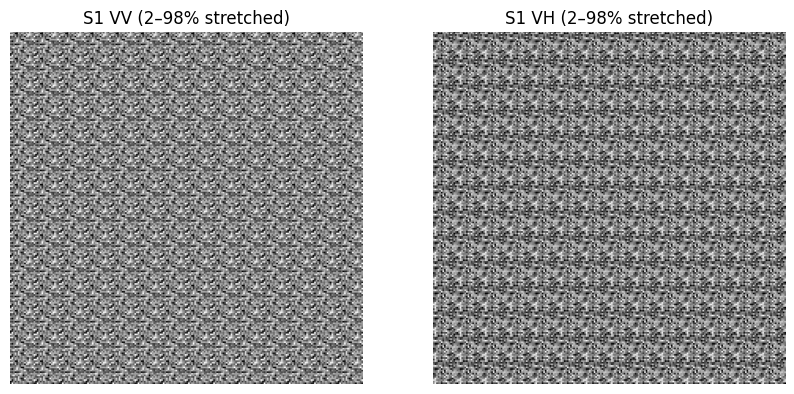

In [32]:
def percentile_stretch(img, pmin=2, pmax=98):
    """퍼센타일 스트레칭 (ArcGIS와 비슷한 효과)"""
    vmin, vmax = np.percentile(img, (pmin, pmax))
    img = np.clip(img, vmin, vmax)
    return (img - vmin) / (vmax - vmin + 1e-6)

s1_pred = s1_pred.squeeze(0)

vv_raw = percentile_stretch(s1_pred[0].cpu().numpy(), 2, 98)
vh_raw = percentile_stretch(s1_pred[1].cpu().numpy(), 2, 98)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(vv_raw, cmap="gray")
axs[0].set_title("S1 VV (2–98% stretched)")
axs[0].axis("off")

axs[1].imshow(vh_raw, cmap="gray")
axs[1].set_title("S1 VH (2–98% stretched)")
axs[1].axis("off")

plt.show()


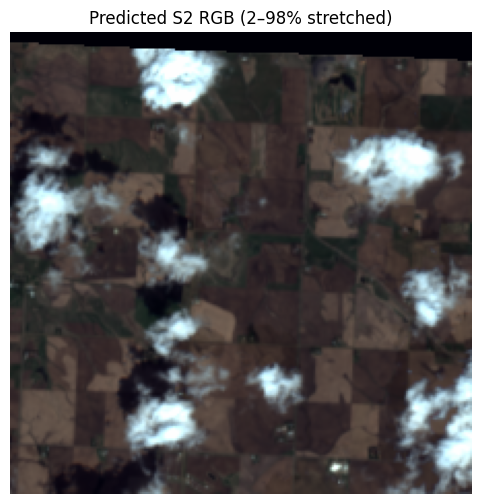

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def percentile_stretch(img, pmin=2, pmax=98):
    """퍼센타일 스트레칭"""
    vmin, vmax = np.percentile(img, (pmin, pmax))
    img = np.clip(img, vmin, vmax)
    return (img - vmin) / (vmax - vmin + 1e-6)

# s2_pred: [1, 12, H, W] normalized prediction
s2_out = s2_patch[0].cpu().numpy()   # [12,224,224]

# Sentinel-2 RGB (B04=Red, B03=Green, B02=Blue)
red   = s2_out[3]  # B04
green = s2_out[2]  # B03
blue  = s2_out[1]  # B02

rgb = np.stack([red, green, blue], axis=-1)

# 퍼센타일 스트레칭
rgb_stretched = percentile_stretch(rgb, 2, 98)

plt.figure(figsize=(6,6))
plt.imshow(rgb_stretched)
plt.title("Predicted S2 RGB (2–98% stretched)")
plt.axis("off")
plt.show()
